# Задание 3
- Найти описание одного из алгоритмов БПФ и реализовать.

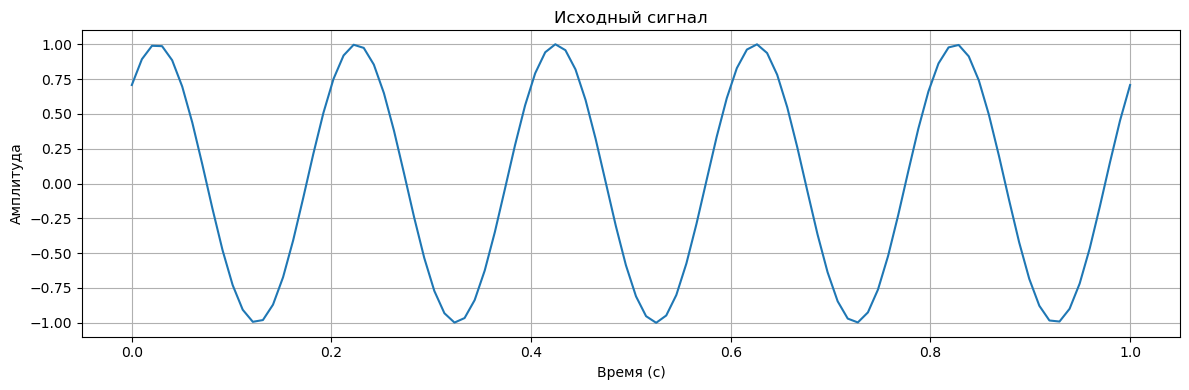

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import time

A0 = 1.0
f0 = 2.0
omega0 = 5.0 * np.pi * f0
phi0 = np.pi / 4
duration = 1.0
sampling_rate = 100.0

num_samples = int(sampling_rate * duration)
t = np.linspace(0, duration, num_samples)
y = A0 * np.sin(omega0 * t + phi0)

plt.figure(figsize=(12, 4))
plt.plot(t, y, linewidth=1.5)
plt.title('Исходный сигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.tight_layout()


Время выполнения: 0.0014684200286865234


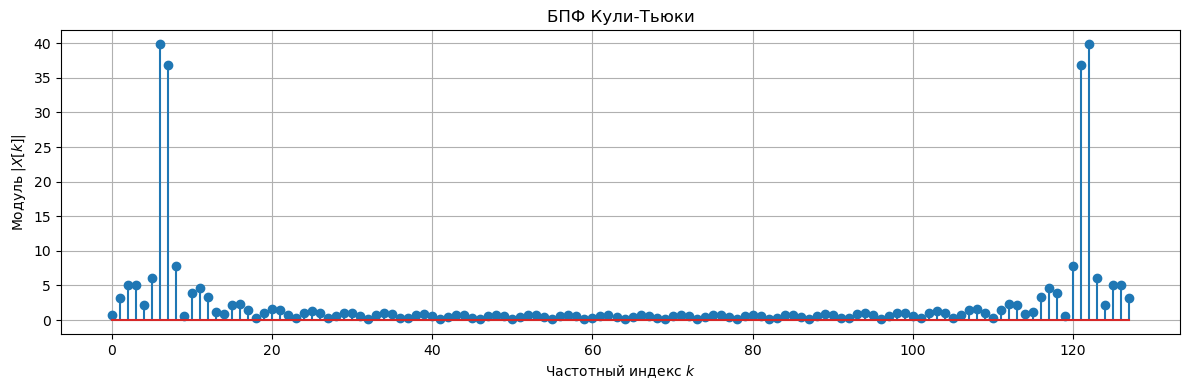

In [34]:
def fft_iterative(x):
    x = np.asarray(x, dtype=complex)
    N = len(x)
    
    start_time = time.time()
    
    if N & (N - 1) != 0:
        M = 1 << (N - 1).bit_length()
        x = np.pad(x, (0, M - N), mode='constant')
        N = M
        
    bits = int(np.log2(N))
    indices = np.array([int(format(i, f'0{bits}b')[::-1], 2) for i in range(N)])
    x = x[indices]
    
    length = 2
    while length <= N:
        half_len = length // 2
        for i in range(0, N, length):
            for j in range(half_len):
                w = np.exp(-2j * np.pi * j / length)
                u = x[i + j]
                v = x[i + j + half_len] * w
                x[i + j] = u + v
                x[i + j + half_len] = u - v
        length *= 2

    end_time = time.time()
    print(f"Время выполнения: {end_time-start_time}")
        
    return x

Y_fft = fft_iterative(y)

N = len(Y_fft)
k_axis = np.arange(N)

plt.figure(figsize=(12, 4))
plt.stem(k_axis, np.abs(Y_fft))
plt.title('БПФ Кули-Тьюки')
plt.xlabel('Частотный индекс $k$')
plt.ylabel('Модуль $|X[k]|$')
plt.grid(True)
plt.tight_layout()